In [180]:
import pandas as pd
import re
import time
import json
import requests
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import openpyxl

## Обработка сырых данных

### Обработка резюме

In [181]:
df = pd.read_csv('data/data_rezume.csv')

In [182]:
df.head()

,id,resume_url,header_text,wrapper_text,created_at,updated_at
0,1,https://hh.ru/resume/3bab3ab0000908964c0039ed1...,"Был сегодня в 14:55\nКандидат\nМужчина, 27 лет...",Аналитик\nСпециализации:\nАналитик\nТип занято...,2026-02-23 17:13:27.709 +0300,2026-02-23 17:13:27.709 +0300
1,2,https://hh.ru/resume/c0d0ac9b0002b4446d0039ed1...,"Был меньше недели назад\nКандидат\nМужчина, 32...",Аналитик данных\nСпециализации:\nАналитик\nТип...,2026-02-23 17:14:55.601 +0300,2026-02-23 17:14:55.601 +0300
2,3,https://hh.ru/resume/a28fcb6700084b93170039ed1...,"Была меньше недели назад\nКандидат\nЖенщина, 3...",Аналитик данных\n300 000 ₽ на руки\nСпециализа...,2026-02-23 17:15:11.186 +0300,2026-02-23 17:15:11.186 +0300
3,4,https://hh.ru/resume/b1b0872200090d4ab70039ed1...,"Был меньше недели назад\nКандидат\nМужчина, 24...",Аналитик данных\n180 000 ₽ на руки\nСпециализа...,2026-02-23 17:15:27.759 +0300,2026-02-23 17:15:27.759 +0300
4,5,https://hh.ru/resume/a0c1974500055dfbf30039ed1...,"Был сегодня в 11:49\nКандидат\nМужчина, 36 лет...",Аналитик\n150 000 ₽ на руки\nСпециализации:\nB...,2026-02-23 17:15:42.736 +0300,2026-02-23 17:15:42.736 +0300


In [183]:
df.shape

(104887, 6)

Из текста карточек резюме извлекаем следующие атрибуты:
- Название вакансии resume_title
- Навыки, указанные в резюме skills_list
- Опыт работы experience_text
- Специализации в резюме specializations_list
- Гражданство citizenship

In [184]:
df['resume_title'] = (
    df['wrapper_text']
    .fillna('')
    .astype(str)
    .str.split('\n')
    .str[0]
    .str.strip()
)

In [185]:
def extract_skills(text):
    text = str(text)
    match = re.search(r'Навыки\s*(.*?)\s*Обо мне', text, flags=re.S)
    if not match:
        return None
    block = match.group(1).strip()
    skills = []
    for line in block.split('\n'):
        line = line.strip()
        if not line:
            continue
        if line == 'Уровни владения навыками':
            continue
        skills.append(line)
    return skills if skills else None

df['skills_list'] = df['wrapper_text'].apply(extract_skills)

In [186]:
def extract_skills(text):
    if pd.isna(text):
        return None
    
    text = str(text)

    start_match = re.search(r'(?m)^Навыки\s*$', text)
    if not start_match:
        return None

    start = start_match.end()

    end_match = re.search(
        r'(?m)^(Обо мне|Опыт вождения|Высшее образование.*|Знание языков|Гражданство, время в пути до работы)\s*$',
        text[start:]
    )

    if end_match:
        block = text[start:start + end_match.start()]
    else:
        block = text[start:]

    lines = []
    skip_lines = {
        'Уровни владения навыками',
        'Продвинутый уровень',
        'Средний уровень',
        'Начальный уровень'
    }

    for line in block.split('\n'):
        line = line.strip()
        if not line:
            continue
        if line in skip_lines:
            continue
        lines.append(line)

    skills = list(dict.fromkeys(lines))

    return skills if skills else None

df['skills_list'] = df['wrapper_text'].apply(extract_skills)

In [187]:
def normalize_skills(skills):
    if not isinstance(skills, list):
        return []
    
    result = []
    seen = set()

    for skill in skills:
        if not isinstance(skill, str):
            continue
        skill = skill.strip().lower()
        if not skill:
            continue
        if skill not in seen:
            seen.add(skill)
            result.append(skill)
    
    return result

df["skills_list"] = df["skills_list"].apply(normalize_skills)

In [188]:
def extract_specializations(text):
    text = str(text)
    match = re.search(
        r'Специализац(?:ия|ии):\s*(.*?)\nТип занятости',
        text,
        flags=re.S
    )
    if not match:
        return None
    block = match.group(1).strip()   
    specializations = []
    for line in block.split('\n'):
        line = line.strip()
        if line:
            specializations.append(line)
    return specializations if specializations else None

df['specializations_list'] = df['wrapper_text'].apply(extract_specializations)

In [189]:
def extract_experience_text(text):
    text = str(text).lower()
    match = re.search(r'опыт работы\s*([^\\n]*)', text)
    if not match:
        return None
    block = match.group(1)
    years = re.search(r'(\d+)\s*(год|года|лет)', block)
    months = re.search(r'(\d+)\s*(месяц|месяца|месяцев)', block)

    y = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0
    if y == 0 and m == 0:
        return None
    return round(y + m / 12, 2)

df['experience_text'] = df['wrapper_text'].apply(extract_experience_text)

In [190]:
def extract_citizenship(text):
    text = str(text)
    match = re.search(
        r'Гражданство, время в пути до работы\s*\nГражданство:\s*(.*)',
        text
    )
    if match:
        return match.group(1).strip()
    return None

df['citizenship'] = df['wrapper_text'].apply(extract_citizenship)

#### Отбор релевантных резюме

Так как в датасете встречается очень много нерелевантных резюме (не относящихся к области анализа данных и работы с данными), необходимо оставить только нужные

Для начала оставим только те резюме, в названии которых присутствуют заголовки, используемые в парсинге (без учета регистра, если хотя бы заголовок парсинга просто встречался в заголовке вакансии)

In [191]:
prof_list = [
    'Аналитик DWH',
    'SQL Analyst',
    'Аналитик больших данных',
    'Специалист по анализу данных',
    'Data Scientist',
    'Data Engineer',
    'BI Developer',
    'ML Engineer',
    'Аналитик данных',
    'Data Analyst',
    'BI-аналитик',
    'Продуктовый аналитик'
]

pattern = r'(^|\b)(' + '|'.join(re.escape(x) for x in prof_list) + r')($|\b)'

mask = df['resume_title'].fillna('').str.contains(
    pattern,
    case=False,
    regex=True
)

df_new = df[mask].copy()

C:\Temp\ipykernel_16560\2903095158.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['resume_title'].fillna('').str.contains(


In [192]:
df_rez = df_new.copy()

#### Обработка текста тела резюме

In [193]:
def clean_resume_text(text):
    text = re.sub(
        r"^.*?тип занятости\s*:.*?\n",
        " ",
        text,
        flags=re.IGNORECASE | re.DOTALL
    ) # Удаление до строки "Тип занятости: ..." включительно
    text = re.sub(
        r"опыт работы\s+"
        r"(?:(?:\d+)\s+(?:года|год|лет)\s*)?"
        r"(?:(?:\d+)\s+(?:месяцев|месяца|месяц)\s*)?",
        " ",
        text,
        flags=re.IGNORECASE
    ) # Удаление строки "Опыт работы ..." с годами и/или месяцами
    text = re.sub(
        r"гражданство,\s*время в пути до работы.*$",
        " ",
        text,
        flags=re.IGNORECASE | re.DOTALL
    ) # Удаление после "Гражданство, время в пути до работы"
    text = re.sub(
        r"показать\s+еще",
        " ",
        text,
        flags=re.IGNORECASE
    ) # Удаление "Показать еще"
    text = re.sub(
        r"\b\d+\s+(?:года|год|лет)\s*(?:\d+\s+(?:месяцев|месяца|месяц))?\b"
        r"|\b\d+\s+(?:месяцев|месяца|месяц)\b",
        " ",
        text,
        flags=re.IGNORECASE
    ) # Удаление длительности работы: "1 год 6 месяцев", "3 года", "11 месяцев"
    text = re.sub(
        r"знание языков.*?(?=повышение квалификации,\s*курсы|$)",
        " ",
        text,
        flags=re.IGNORECASE | re.DOTALL
    )
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\b\S+@\S+\.\S+\b", " ", text)
    text = re.sub(r"[^a-zа-яё0-9+#.\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [194]:
# Для теста
# df_rez["text_clean_test"] = df_rez["wrapper_text"].apply(clean_resume_text)

In [195]:
df_rez["text_clean"] = df_rez["wrapper_text"].apply(clean_resume_text)

Также при ручном разборе выявлены мусорные фразы HH (а также Яндекса), уберем их

In [196]:
def clean_text_resume_extra(text):
    # удаляем интерфейс hh
    trash_phrases = [
        "показать еще",
        "скрыть",
        "редактировать",
        "резюме на hh",
        "обновлено",
        "настоящее время"
    ]

    for phrase in trash_phrases:
        text = text.replace(phrase, " ")

    # удаляем личную инфу
    text = re.sub(
        r"\b(гражданство|дата рождения|пол)\b\s*:?.*",
        " ",
        text
    )
    text = re.sub(r"готов к переезду.*", " ", text)
    text = re.sub(r"не готов к командировкам.*", " ", text)

    # удаляем блок "обо мне"
    text = re.sub(r"обо мне.*?(опыт работы|образование|$)", " ", text, flags=re.DOTALL)

    # удаляем заголовки, но не содержимое
    headers = [
        "опыт работы",
        "образование",
        "ключевые навыки",
        "навыки"
    ]

    for h in headers:
        text = text.replace(h, " ")

    # чистим пробелы
    text = re.sub(r"\s+", " ", text).strip()

    return text

df_rez["text_clean"] = df_rez["text_clean"].apply(clean_text_resume_extra)

In [197]:
df_rez.head()

,id,resume_url,header_text,wrapper_text,created_at,updated_at,resume_title,skills_list,specializations_list,experience_text,citizenship,text_clean
1,2,https://hh.ru/resume/c0d0ac9b0002b4446d0039ed1...,"Был меньше недели назад\nКандидат\nМужчина, 32...",Аналитик данных\nСпециализации:\nАналитик\nТип...,2026-02-23 17:14:55.601 +0300,2026-02-23 17:14:55.601 +0300,Аналитик данных,"[пользователь пк, ms sql, ms office, driving l...",[Аналитик],8.92,Россия,сентябрь 2024 сентябрь 2025 кофемания москва г...
2,3,https://hh.ru/resume/a28fcb6700084b93170039ed1...,"Была меньше недели назад\nКандидат\nЖенщина, 3...",Аналитик данных\n300 000 ₽ на руки\nСпециализа...,2026-02-23 17:15:11.186 +0300,2026-02-23 17:15:11.186 +0300,Аналитик данных,"[ms powerpoint, python, numpy, sql, git, pycha...","[BI-аналитик, аналитик данных, Аналитик, Бизне...",6.50,Россия,апрель 2025 по termoland услуги для населения....
3,4,https://hh.ru/resume/b1b0872200090d4ab70039ed1...,"Был меньше недели назад\nКандидат\nМужчина, 24...",Аналитик данных\n180 000 ₽ на руки\nСпециализа...,2026-02-23 17:15:27.759 +0300,2026-02-23 17:15:27.759 +0300,Аналитик данных,"[data science, регрессионный анализ, проверка ...",[Аналитик],2.67,Россия,декабрь 2024 по центральный банк российской фе...
5,6,https://hh.ru/resume/989115340003c2cb260039ed1...,"Был сегодня в 12:23\nКандидат\nМужчина, 35 лет...",Аналитик данных\n150 000 ₽ на руки\nСпециализа...,2026-02-23 17:15:55.201 +0300,2026-02-23 17:15:55.201 +0300,Аналитик данных,"[sql, power bi, ms power bi, dax, tableau, abc...","[BI-аналитик, аналитик данных, Аналитик, Бизне...",8.17,Россия,январь 2025 по нева дельта спб аналитик сбор о...
7,8,https://hh.ru/resume/29c348910002487e500039ed1...,"Был сегодня в 12:54\nКандидат\nМужчина, 39 лет...","Аналитик данных\nСпециализации:\nBI-аналитик, ...",2026-02-23 17:16:25.280 +0300,2026-02-23 17:16:25.280 +0300,Аналитик данных,"[python, vba, sql, ms office, oracle, qlik sen...","[BI-аналитик, аналитик данных]",14.42,Россия,октябрь 2011 по сбер москва rabota.sber.ru фин...


### Обработка вакансий

In [198]:
df = pd.read_csv('data/vacant.csv')

In [199]:
df.head()

,id,vacancy_url,header_text,wrapper_text,created_at,updated_at
0,1,https://hh.ru/vacancy/129575262,Старший разработчик в группу GPU-инфраструктур...,Yandex\nInfrastructure\nМы создаём и развиваем...,2026-03-17 21:54:16.843,2026-03-17 21:54:16.843
1,2,https://hh.ru/vacancy/129454986,Project manager по развитию и трансформации би...,Обязанности:\nВыполнение функций project manag...,2026-03-17 21:54:39.568,2026-03-17 21:54:39.568
2,3,https://hh.ru/vacancy/111241834,QA Engineer (со знанием немецкого языка)\nУров...,Team.Inno – одна из наиболее опытных белорусск...,2026-03-17 21:55:04.099,2026-03-17 21:55:04.099
3,4,https://hh.ru/vacancy/129422503,Менеджер по маркетплейсу OZON\nВ архиве с 11 м...,Привет!\nМеня зовут Максим - я селлер на ВБ и ...,2026-03-17 21:55:33.566,2026-03-17 21:55:33.566
4,5,https://hh.ru/vacancy/129356560,Менеджер по закупкам и снабжению\nВ архиве с 1...,Tonka Perfumes Moscow – российский парфюмерный...,2026-03-17 21:56:04.140,2026-03-17 21:56:04.140


In [200]:
df.shape

(16788, 6)

In [201]:
df["header_text_list"] = df["header_text"].fillna("").str.split("\n")

In [202]:
df["header_text_list"] = df["header_text_list"].apply(
    lambda x: [item for item in x if not (isinstance(item, str) and item.startswith("В архиве"))]
    if isinstance(x, list) else x
)

Из текста карточек вакансий извлекаем следующие атрибуты:
 - Наименование vacancy_name
 - Опыт работы experience
 - Указанная вилка по з/п salary
 - Флаг присутствия вилки по з/п salary_exists, от и до salary_from, salary_to
 - Форматт работы work_format
 - Тип занятости employment_type
 - Требуемые навыки skills_list
 - Опыт работы (от скольки лет, числовое представвление) experience_years_min

In [203]:
df["vacancy_name"] = df["header_text_list"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

In [204]:
df["experience"] = df["header_text_list"].apply(
    lambda x: next(
        (
            item.replace("Опыт работы:", "").strip()
            for item in x
            if isinstance(item, str) and item.startswith("Опыт работы:")
        ),
        None
    ) if isinstance(x, list) else None
)

In [205]:
df["salary"] = df["header_text_list"].apply(
    lambda x: x[1] if isinstance(x, list) and len(x) > 1 else None
)

In [206]:
def parse_salary(text):
    if pd.isna(text) or str(text).strip() == "Уровень дохода не указан":
        return pd.Series([False, None, None])

    text = str(text).strip()

    numbers = re.findall(r"\d[\d\s]*", text)
    numbers = [int(num.replace(" ", "")) for num in numbers]

    if len(numbers) == 0:
        return pd.Series([False, None, None])

    if len(numbers) == 1:
        number = numbers[0]

        if text.startswith("от"):
            return pd.Series([True, number, None])

        if text.startswith("до"):
            return pd.Series([True, None, number])

        return pd.Series([True, number, number])

    return pd.Series([True, numbers[0], numbers[1]])

df[["salary_exists", "salary_from", "salary_to"]] = df["salary"].apply(parse_salary)

In [207]:
df["work_format"] = df["header_text_list"].apply(
    lambda x: x[-1].replace("Формат работы:", "").strip()
    if isinstance(x, list) and len(x) > 0 and isinstance(x[-1], str) and x[-1].startswith("Формат работы:")
    else None
)

In [208]:
df["employment_type"] = df["header_text_list"].apply(
    lambda x: next(
        (item for item in x if isinstance(item, str) and "занятость" in item.lower()),
        None
    ) if isinstance(x, list) else None
)

In [209]:
def parse_skills(text):
    if pd.isna(text):
        return []
    
    text = str(text)
    
    match = re.search(
        r"Ключевые навыки\s*(.*?)\s*Где предстоит работать",
        text,
        flags=re.S
    )
    
    if not match:
        return []
    
    skills_block = match.group(1).strip()
    
    skills = [
        line.strip()
        for line in skills_block.split("\n")
        if line.strip()
    ]
    
    return skills

df["skills_list"] = df["wrapper_text"].apply(parse_skills)

In [210]:
def parse_experience(text):
    if pd.isna(text):
        return None

    text = str(text).lower().strip().replace('–', '-')

    if 'нет опыта' in text or 'не требуется' in text:
        return 0
    if 'более 6' in text:
        return 6

    match = re.search(r'(\d+)\s*-\s*(\d+)', text)
    if match:
        return int(match.group(1))

    match = re.search(r'от\s*(\d+)', text)
    if match:
        return int(match.group(1))

    return None

df['experience_years_min'] = df['experience'].apply(parse_experience)

#### Отбор релевантных вакансий

Так же, как и с резюме, при парсинге получили большое количество нерелевантных вакансий

Поэтому поступим для начала так же - отберем вакансии по заголовку парсинга

In [211]:
prof_list = [
    'Аналитик DWH',
    'SQL Analyst',
    'Аналитик больших данных',
    'Специалист по анализу данных',
    'Data Scientist',
    'Data Engineer',
    'BI Developer',
    'ML Engineer',
    'Аналитик данных',
    'Data Analyst',
    'BI-аналитик',
    'Продуктовый аналитик'
]

pattern = r'(^|\b)(' + '|'.join(re.escape(x) for x in prof_list) + r')($|\b)'

mask = df['vacancy_name'].fillna('').str.contains(
    pattern,
    case=False,
    regex=True
)

df_new = df[mask].copy()

C:\Temp\ipykernel_16560\3057247236.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['vacancy_name'].fillna('').str.contains(


In [212]:
df_vac = df_new.copy()

#### Дополнительная обработка навыков с помощью LLM

In [213]:
OLLAMA_URL = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "qwen2.5:7b"

In [214]:
def is_nonempty_list(x):
    return isinstance(x, list) and len(x) > 0

In [215]:
def remove_key_skills_block(text):
    if pd.isna(text) or not str(text).strip():
        return text
    text = str(text)
    text = re.sub(
        r"Ключевые навыки\s*(.*?)\s*Где предстоит работать",
        " ",
        text,
        flags=re.S
    )
    return text

In [216]:
# Извлечение JSON из ответа модели
def extract_json_object(text):
    try:
        return json.loads(text)
    except:
        pass
    match = re.search(r"\{.*\}", text, flags=re.S)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            return None
    return None

In [217]:
def build_prompt(text):
    text = remove_key_skills_block(text)

    return f"""
Извлеки из текста вакансии только явно указанные профессиональные навыки.

Считать навыками:
- технологии
- инструменты
- языки программирования
- библиотеки
- фреймворки
- базы данных
- BI-инструменты
- методы анализа данных
- платформы и сервисы

Не считать навыками:
- soft skills
- личные качества
- общие фразы вроде "ответственность", "обучаемость", "работа в команде"
- слишком общие слова вроде "анализ", "разработка", "ведение отчетности"

Важно:
- не смотри на блок между "Ключевые навыки" и "Где предстоит работать"
- извлекай навыки из остального текста вакансии

Правила:
1. Не добавляй навыки, которых нет в тексте.
2. Верни только JSON-объект такого вида:
{{"skills": ["skill1", "skill2"]}}
3. Если явных навыков нет, верни:
{{"skills": []}}

Текст вакансии:
{text}
"""

In [218]:
def extract_skills_with_ollama(text, model=OLLAMA_MODEL, timeout=180):
    if pd.isna(text) or not str(text).strip():
        return []

    prompt = build_prompt(text)

    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "format": {
            "type": "object",
            "properties": {
                "skills": {
                    "type": "array",
                    "items": {"type": "string"}
                }
            },
            "required": ["skills"]
        },
        "options": {
            "temperature": 0
        }
    }

    response = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
    response.raise_for_status()

    raw_answer = response.json().get("response", "")
    parsed_answer = extract_json_object(raw_answer)

    if parsed_answer is None:
        return []

    skills = parsed_answer.get("skills", [])

    if not isinstance(skills, list):
        return []

    return skills

In [219]:
if "skills_llm" not in df_vac.columns:
    df_vac["skills_llm"] = None

df_vac["skills_final"] = df_vac["skills_list"].apply(
    lambda x: x if isinstance(x, list) else []
)

In [220]:
mask_no_manual_skills = (
    ~df_vac["skills_list"].apply(is_nonempty_list)
    & df_vac["wrapper_text"].notna()
    & (df_vac["wrapper_text"].str.strip() != "")
)
print("Строк без навыков, найденных вручную:", mask_no_manual_skills.sum())

Строк без навыков, найденных вручную: 865


In [221]:
# LLM для строк, где вручную ничего не нашлось
results_no_manual = []

subset_no_manual = df_vac.loc[mask_no_manual_skills, ["wrapper_text"]].copy()

for i, (idx, text) in enumerate(subset_no_manual["wrapper_text"].items(), start=1):
    try:
        skills = extract_skills_with_ollama(text)
    except Exception as e:
        print(f"Ошибка на индексе {idx}: {e}")
        skills = []

    results_no_manual.append((idx, skills))

    if i % 20 == 0:
        print(f"Обработано {i} из {len(subset_no_manual)}")

Обработано 20 из 865
Обработано 40 из 865
Обработано 60 из 865
Обработано 80 из 865
Обработано 100 из 865
Обработано 120 из 865
Обработано 140 из 865
Обработано 160 из 865
Обработано 180 из 865
Обработано 200 из 865
Обработано 220 из 865
Обработано 240 из 865
Обработано 260 из 865
Обработано 280 из 865
Обработано 300 из 865
Обработано 320 из 865
Обработано 340 из 865
Обработано 360 из 865
Обработано 380 из 865
Обработано 400 из 865
Обработано 420 из 865
Обработано 440 из 865
Обработано 460 из 865
Обработано 480 из 865
Обработано 500 из 865
Обработано 520 из 865
Обработано 540 из 865
Обработано 560 из 865
Обработано 580 из 865
Обработано 600 из 865
Обработано 620 из 865
Обработано 640 из 865
Обработано 660 из 865
Обработано 680 из 865
Обработано 700 из 865
Обработано 720 из 865
Обработано 740 из 865
Обработано 760 из 865
Обработано 780 из 865
Обработано 800 из 865
Обработано 820 из 865
Обработано 840 из 865
Обработано 860 из 865


In [222]:
for idx, skills in results_no_manual:
    df_vac.at[idx, "skills_llm"] = skills
    df_vac.at[idx, "skills_final"] = skills if isinstance(skills, list) else []

In [223]:
mask_manual_skills = (
    df_vac["skills_list"].apply(is_nonempty_list)
    & df_vac["wrapper_text"].notna()
    & (df_vac["wrapper_text"].str.strip() != "")
)

print("Строк с навыками, найденными вручную:", mask_manual_skills.sum())

Строк с навыками, найденными вручную: 600


In [224]:
# LLM для строк, где вручную навыки уже нашлись
results_with_manual = []

subset_with_manual = df_vac.loc[mask_manual_skills, ["wrapper_text"]].copy()

for i, (idx, text) in enumerate(subset_with_manual["wrapper_text"].items(), start=1):
    try:
        skills = extract_skills_with_ollama(text)
    except Exception as e:
        print(f"Ошибка на индексе {idx}: {e}")
        skills = []

    results_with_manual.append((idx, skills))

    if i % 20 == 0:
        print(f"Обработано {i} из {len(subset_with_manual)}")

Обработано 20 из 600
Обработано 40 из 600
Обработано 60 из 600
Обработано 80 из 600
Обработано 100 из 600
Обработано 120 из 600
Обработано 140 из 600
Обработано 160 из 600
Обработано 180 из 600
Обработано 200 из 600
Обработано 220 из 600
Обработано 240 из 600
Обработано 260 из 600
Обработано 280 из 600
Обработано 300 из 600
Обработано 320 из 600
Обработано 340 из 600
Обработано 360 из 600
Обработано 380 из 600
Обработано 400 из 600
Обработано 420 из 600
Обработано 440 из 600
Обработано 460 из 600
Обработано 480 из 600
Обработано 500 из 600
Обработано 520 из 600
Обработано 540 из 600
Обработано 560 из 600
Обработано 580 из 600
Обработано 600 из 600


In [225]:
for idx, skills in results_with_manual:
    df_vac.at[idx, "skills_llm"] = skills

    current_skills = df_vac.at[idx, "skills_final"]
    current_skills = current_skills if isinstance(current_skills, list) else []

    llm_skills = skills if isinstance(skills, list) else []

    merged = current_skills + llm_skills

    final_result = []
    seen = set()

    for skill in merged:
        if not isinstance(skill, str):
            continue

        skill = skill.strip().lower()

        if not skill:
            continue

        if skill not in seen:
            seen.add(skill)
            final_result.append(skill)

    df_vac.at[idx, "skills_final"] = final_result

In [226]:
def lowercase_and_deduplicate(skills):
    if not isinstance(skills, list):
        return []

    result = []
    seen = set()

    for skill in skills:
        if not isinstance(skill, str):
            continue

        skill = skill.strip().lower()

        if not skill:
            continue

        if skill not in seen:
            seen.add(skill)
            result.append(skill)

    return result

In [227]:
df_vac["skills_final"] = df_vac["skills_final"].apply(lowercase_and_deduplicate)

#### Обработка текста тела вакансий

In [228]:
# df_vac = pd.read_csv('df_vac_intermediate.csv')
df_vac.head()

,id,vacancy_url,header_text,wrapper_text,created_at,updated_at,header_text_list,vacancy_name,experience,salary,salary_exists,salary_from,salary_to,work_format,employment_type,skills_list,experience_years_min,skills_llm,skills_final
16,15,https://hh.ru/vacancy/129592277,Аналитик данных / экономист инвестиционных про...,46\nорганов исполнительной власти\n132\nтеррит...,2026-03-17 22:02:49.589,2026-03-17 22:02:49.589,[Аналитик данных / экономист инвестиционных пр...,Аналитик данных / экономист инвестиционных про...,1–3 года,Уровень дохода не указан,False,NaN,NaN,на месте работодателя,Полная занятость,[],1.0,"[Python, Django, Pandas, MS Office (Power Poin...","[python, django, pandas, ms office (power poin..."
34,34,https://hh.ru/vacancy/129853395,Data Engineer (разработчик DWH)\nВ архиве с 17...,Задаем тренды в технологиях ритейла\nX5 Group ...,2026-03-17 22:13:18.663,2026-03-17 22:13:18.663,"[Data Engineer (разработчик DWH), Уровень дохо...",Data Engineer (разработчик DWH),3–6 лет,Уровень дохода не указан,False,NaN,NaN,"на месте работодателя, удалённо или гибрид",Полная занятость,"[SQL, Python, Big Data, Apache Airflow, Apache...",3.0,"[Spark, Flink, ClickHouse, Kafka, Trino, Apach...","[sql, python, big data, apache airflow, apache..."
47,92,https://hh.ru/vacancy/129525525,Аналитик данных\nВ архиве с 15 февраля 2026\nУ...,Центр Компетенций Бизнес аналитики и финансово...,2026-03-17 22:56:00.590,2026-03-17 22:56:00.590,"[Аналитик данных, Уровень дохода не указан, Оп...",Аналитик данных,1–3 года,Уровень дохода не указан,False,NaN,NaN,на месте работодателя,Полная занятость,[],1.0,"[SQL, Python, Hadoop, Excel]","[sql, python, hadoop, excel]"
64,162,https://hh.ru/vacancy/130038332,Data Engineer по построению DWH\nУровень доход...,Компания EcoFinance развивает и внедряет проду...,2026-03-17 23:43:51.117,2026-03-17 23:43:51.117,"[Data Engineer по построению DWH, Уровень дохо...",Data Engineer по построению DWH,3–6 лет,Уровень дохода не указан,False,NaN,NaN,гибрид,Полная занятость,"[ETL, SQL, DWH, Apache Kafka, Debezium, BI, db...",3.0,"[PostgreSQL, Kafka, Debezium, dbt, Airflow, Fi...","[etl, sql, dwh, apache kafka, debezium, bi, db..."
69,65,https://hh.ru/vacancy/130308940,Senior Data Scientist\nВ архиве с 12 марта 202...,СОЗДАВАЙ ИННОВАЦИИ В АТМОСФЕРЕ СВОБОДЫ —\nИ РА...,2026-03-17 22:38:38.542,2026-03-17 22:38:38.542,"[Senior Data Scientist, Уровень дохода не указ...",Senior Data Scientist,1–3 года,Уровень дохода не указан,False,NaN,NaN,NaN,Полная занятость,[],1.0,"[Python, ML-библиотеки, SQL]","[python, ml-библиотеки, sql]"


In [229]:
df_vac["text_clean"] = (
    df_vac["wrapper_text"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

Также при ручном разборе выявлены мусорные фразы HH (а также Яндекса), уберем их

In [230]:
def clean_text_vacancy_extra(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Удаляем блок вопросов работодателю
    text = re.sub(
        r"задайте вопрос работодателю.*?(другой вопрос)?",
        " ",
        text,
        flags=re.DOTALL
    )

    # Удаляем блок адреса/карты
    text = re.sub(
        r"где предстоит работать.*",
        " ",
        text,
        flags=re.DOTALL
    )

    # Удаляем яндекс-карту
    text = re.sub(r"© яндекс.*", " ", text, flags=re.DOTALL)
    text = re.sub(r"показать на большой карте", " ", text)

    # Удаляем отдельные служебные слова
    trash_phrases = [
        "он получит его с откликом на вакансию",
        "где располагается место работы?",
        "какой график работы?",
        "вакансия открыта?",
        "какая оплата труда?",
        "как с вами связаться?",
        "другой вопрос",
        "откликнуться",
        "доступно соискателям с инвалидностью"
    ]

    for phrase in trash_phrases:
        text = text.replace(phrase, " ")

    # Чистим лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()

    return text

df_vac["text_clean"] = df_vac["text_clean"].apply(clean_text_vacancy_extra)

In [231]:
df_vac

,id,vacancy_url,header_text,wrapper_text,created_at,updated_at,header_text_list,vacancy_name,experience,salary,salary_exists,salary_from,salary_to,work_format,employment_type,skills_list,experience_years_min,skills_llm,skills_final,text_clean
16,15,https://hh.ru/vacancy/129592277,Аналитик данных / экономист инвестиционных про...,46\nорганов исполнительной власти\n132\nтеррит...,2026-03-17 22:02:49.589,2026-03-17 22:02:49.589,[Аналитик данных / экономист инвестиционных пр...,Аналитик данных / экономист инвестиционных про...,1–3 года,Уровень дохода не указан,False,NaN,NaN,на месте работодателя,Полная занятость,[],1.0,"[Python, Django, Pandas, MS Office (Power Poin...","[python, django, pandas, ms office (power poin...",46 органов исполнительной власти 132 территори...
34,34,https://hh.ru/vacancy/129853395,Data Engineer (разработчик DWH)\nВ архиве с 17...,Задаем тренды в технологиях ритейла\nX5 Group ...,2026-03-17 22:13:18.663,2026-03-17 22:13:18.663,"[Data Engineer (разработчик DWH), Уровень дохо...",Data Engineer (разработчик DWH),3–6 лет,Уровень дохода не указан,False,NaN,NaN,"на месте работодателя, удалённо или гибрид",Полная занятость,"[SQL, Python, Big Data, Apache Airflow, Apache...",3.0,"[Spark, Flink, ClickHouse, Kafka, Trino, Apach...","[sql, python, big data, apache airflow, apache...",задаем тренды в технологиях ритейла x5 group —...
47,92,https://hh.ru/vacancy/129525525,Аналитик данных\nВ архиве с 15 февраля 2026\nУ...,Центр Компетенций Бизнес аналитики и финансово...,2026-03-17 22:56:00.590,2026-03-17 22:56:00.590,"[Аналитик данных, Уровень дохода не указан, Оп...",Аналитик данных,1–3 года,Уровень дохода не указан,False,NaN,NaN,на месте работодателя,Полная занятость,[],1.0,"[SQL, Python, Hadoop, Excel]","[sql, python, hadoop, excel]",центр компетенций бизнес аналитики и финансово...
64,162,https://hh.ru/vacancy/130038332,Data Engineer по построению DWH\nУровень доход...,Компания EcoFinance развивает и внедряет проду...,2026-03-17 23:43:51.117,2026-03-17 23:43:51.117,"[Data Engineer по построению DWH, Уровень дохо...",Data Engineer по построению DWH,3–6 лет,Уровень дохода не указан,False,NaN,NaN,гибрид,Полная занятость,"[ETL, SQL, DWH, Apache Kafka, Debezium, BI, db...",3.0,"[PostgreSQL, Kafka, Debezium, dbt, Airflow, Fi...","[etl, sql, dwh, apache kafka, debezium, bi, db...",компания ecofinance развивает и внедряет проду...
69,65,https://hh.ru/vacancy/130308940,Senior Data Scientist\nВ архиве с 12 марта 202...,СОЗДАВАЙ ИННОВАЦИИ В АТМОСФЕРЕ СВОБОДЫ —\nИ РА...,2026-03-17 22:38:38.542,2026-03-17 22:38:38.542,"[Senior Data Scientist, Уровень дохода не указ...",Senior Data Scientist,1–3 года,Уровень дохода не указан,False,NaN,NaN,NaN,Полная занятость,[],1.0,"[Python, ML-библиотеки, SQL]","[python, ml-библиотеки, sql]",создавай инновации в атмосфере свободы — и рас...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16757,16757,https://hh.ru/vacancy/131551598,Senior Data Scientist\nУровень дохода не указа...,"Мы в поиске специалиста по Data Science, котор...",2026-04-22 14:34:30.769,2026-04-22 14:34:30.769,"[Senior Data Scientist, Уровень дохода не указ...",Senior Data Scientist,не требуется,Уровень дохода не указан,False,NaN,NaN,на месте работодателя,Полная занятость,[],0.0,"[Python, pytorch, pandas, numpy, SQLAlchemy, S...","[python, pytorch, pandas, numpy, sqlalchemy, s...","мы в поиске специалиста по data science, котор..."
16759,16759,https://hh.ru/vacancy/132015906,Стажер Data Engineer\nУровень дохода не указан...,Стажировка в T2 — это полноценная оплачиваемая...,2026-04-22 14:34:52.526,2026-04-22 14:34:52.526,"[Стажер Data Engineer, Уровень дохода не указа...",Стажер Data Engineer,не требуется,Уровень дохода не указан,False,NaN,NaN,на месте работодателя или гибрид,Полная занятость,[],0.0,"[SQL, Python]","[sql, python]",стажировка в t2 — это полноценная оплачиваемая...
16760,16760,https://hh.ru/vacancy/131675291,Стажер Data Engineer\nУровень дохода не указан...,ДАВАЙ С НАМИ\nМы я

In [232]:
df_rez = df_rez[['id', 'resume_title', 'text_clean', 'skills_list', 'experience_text']]
df_vac = df_vac[['id', 'vacancy_name', 'text_clean', 'skills_final', 'experience_years_min']]

## EDA по полученным датасетам

### Общая информация

In [233]:
eda_summary = pd.DataFrame({
    "Датасет": ["Резюме", "Вакансии"],
    "Строк": [len(df_rez), len(df_vac)],
    "Колонок": [df_rez.shape[1], df_vac.shape[1]]
})

eda_summary

,Датасет,Строк,Колонок
0,Резюме,11940,5
1,Вакансии,1465,5


In [234]:
df_rez.info()

<class 'pandas.DataFrame'>
Index: 11940 entries, 1 to 104886
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               11940 non-null  int64  
 1   resume_title     11940 non-null  object 
 2   text_clean       11940 non-null  str    
 3   skills_list      11940 non-null  object 
 4   experience_text  10319 non-null  float64
dtypes: float64(1), int64(1), object(2), str(1)
memory usage: 559.7+ KB


In [235]:
df_vac.info()

<class 'pandas.DataFrame'>
Index: 1465 entries, 16 to 16767
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1465 non-null   int64  
 1   vacancy_name          1465 non-null   str    
 2   text_clean            1465 non-null   str    
 3   skills_final          1465 non-null   object 
 4   experience_years_min  1464 non-null   float64
dtypes: float64(1), int64(1), object(1), str(2)
memory usage: 101.0+ KB


Проверка пропусков

In [236]:
df_rez.isna().sum()

id                    0
resume_title          0
text_clean            0
skills_list           0
experience_text    1621
dtype: int64

In [237]:
df_vac.isna().sum()

id                      0
vacancy_name            0
text_clean              0
skills_final            0
experience_years_min    1
dtype: int64

### Анализ текстов

In [238]:
def add_text_stats(df, text_col="text_clean"):
    df = df.copy()
    def count_words(text):
        text = str(text).lower()
        words = re.findall(r"[а-яёa-z0-9+#.]+", text)
        return len(words)
    
    def avg_word_len(text):
        text = str(text).lower()
        words = re.findall(r"[а-яёa-z0-9+#.]+", text)
        return np.mean([len(word) for word in words])
    
    def latin(text):
        text = str(text).lower()
        all_letters = re.findall(r"[а-яёa-z]", text)
        latin_letters = re.findall(r"[a-z]", text)
        if len(all_letters) == 0:
            return 0
        return len(latin_letters) / len(all_letters)

    df["text_len"] = df[text_col].str.len()
    df["word_count"] = df[text_col].apply(count_words)
    df["avg_word_len"] = df[text_col].apply(avg_word_len)
    df["latin_share"] = df[text_col].apply(latin)

    return df

In [239]:
df_rez = add_text_stats(df_rez, text_col="text_clean")
df_vac = add_text_stats(df_vac, text_col="text_clean")

In [240]:
pd.DataFrame({
    "длина резюме": df_rez["text_len"].describe(),
    "длина вакансий": df_vac["text_len"].describe(),
    "количество слов в резюме": df_rez["word_count"].describe(),
    "количество слов в вакансиях": df_vac["word_count"].describe(),
    "доля латиницы в резюме": df_rez["latin_share"].describe(),
    "доля латиницы в вакансиях": df_vac["latin_share"].describe()
})

,длина резюме,длина вакансий,количество слов в резюме,количество слов в вакансиях,доля латиницы в резюме,доля латиницы в вакансиях
count,11940.000000,1465.000000,11940.000000,1465.000000,11940.000000,1465.000000
mean,3405.938107,2533.217065,436.423953,333.802730,0.232063,0.114116
std,2517.116840,968.781972,329.108581,130.566379,0.280739,0.176089
min,84.000000,447.000000,11.000000,48.000000,0.000000,0.000000
25%,1764.000000,1883.000000,224.000000,244.000000,0.067944,0.044706
50%,2813.000000,2393.000000,360.000000,314.000000,0.125394,0.072183
75%,4419.000000,3027.000000,565.250000,400.000000,0.227017,0.111066
max,20130.000000,7811.000000,2656.000000,1087.000000,1.000000,1.000000


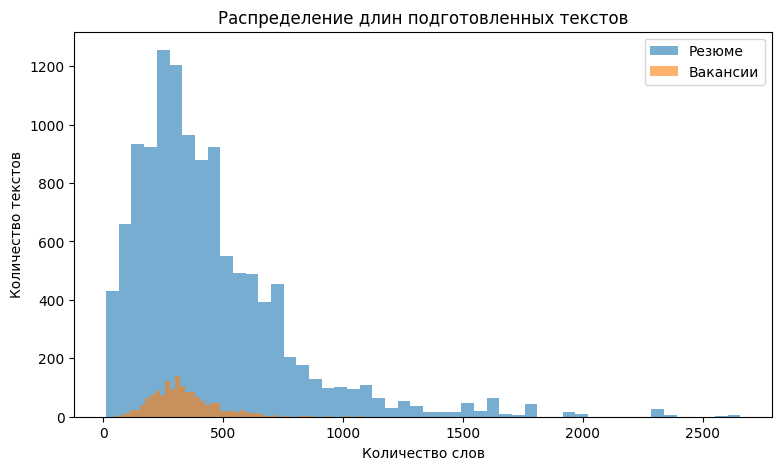

In [241]:
plt.figure(figsize=(9, 5))
plt.hist(df_rez["word_count"], bins=50, alpha=0.6, label="Резюме")
plt.hist(df_vac["word_count"], bins=50, alpha=0.6, label="Вакансии")
plt.title("Распределение длин подготовленных текстов")
plt.xlabel("Количество слов")
plt.ylabel("Количество текстов")
plt.legend()
plt.show()

Видим, что у резюме есть длинный правый хвост. Проаназировав данные тексты, видно, что это подробные резюме.

Следует больше внимания обратить на шумы

In [242]:
long_resumes = (
    df_rez
    .sort_values("word_count", ascending=False)
    .head(50)
    [["resume_title", "word_count", "skills_list", "text_clean"]]
)

long_resumes.to_excel("long_resumes.xlsx", index=False)

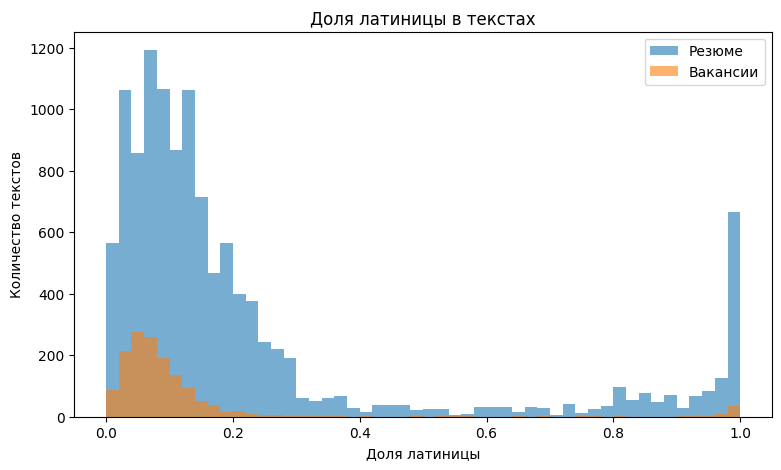

In [243]:
plt.figure(figsize=(9, 5))
plt.hist(df_rez["latin_share"], bins=50, alpha=0.6, label="Резюме")
plt.hist(df_vac["latin_share"], bins=50, alpha=0.6, label="Вакансии")
plt.title("Доля латиницы в текстах")
plt.xlabel("Доля латиницы")
plt.ylabel("Количество текстов")
plt.legend()
plt.show()

Видно, что есть резюме и вакансии с высоким содержанием латиницы (а некоторые - полоностью на английском). Удалим тексты с большим содержанием латиницы > 0.4)

In [244]:
latin_threshold = 0.4
rez_high_latin_count = (df_rez["latin_share"] > latin_threshold).sum()
vac_high_latin_count = (df_vac["latin_share"] > latin_threshold).sum()

print("Порог доли латиницы:", latin_threshold)

print("Резюме к удалению:", rez_high_latin_count)
print("Доля резюме к удалению:", round(rez_high_latin_count / len(df_rez), 3))

print("Вакансии к удалению:", vac_high_latin_count)
print("Доля вакансий к удалению:", round(vac_high_latin_count / len(df_vac), 3))

Порог доли латиницы: 0.4
Резюме к удалению: 1822
Доля резюме к удалению: 0.153
Вакансии к удалению: 61
Доля вакансий к удалению: 0.042


In [245]:
df_rez = df_rez[df_rez["latin_share"] <= latin_threshold].copy()
df_vac = df_vac[df_vac["latin_share"] <= latin_threshold].copy()

In [246]:
print(df_rez.shape)
print(df_vac.shape)

(10118, 9)
(1404, 9)


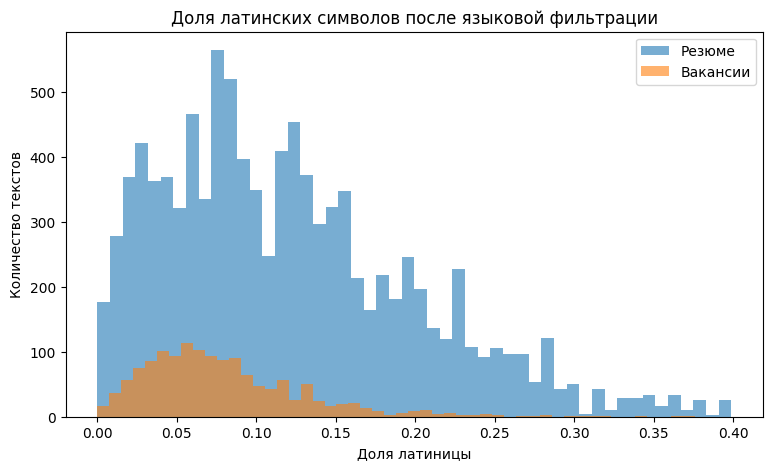

In [247]:
plt.figure(figsize=(9, 5))

plt.hist(df_rez["latin_share"], bins=50, alpha=0.6, label="Резюме")
plt.hist(df_vac["latin_share"], bins=50, alpha=0.6, label="Вакансии")

plt.title("Доля латинских символов после языковой фильтрации")
plt.xlabel("Доля латиницы")
plt.ylabel("Количество текстов")
plt.legend()
plt.show()

### Частотный анализ слов

In [248]:
stopwords = [
    # русские служебные слова
    "и", "в", "во", "на", "с", "со", "по", "для", "как", "что", "это",
    "от", "до", "из", "за", "при", "или", "а", "но", "также", "к", "у",
    "о", "об", "не", "мы", "вы", "они", "он", "она", "оно", "их", "его",
    "ее", "мой", "моя", "мои", "наш", "ваш", "быть", "был", "была",
    "были", "есть", "будет",
    # частые слова из резюме/вакансий, которые мало помогают анализу
    "работа", "работы", "работать", "работал", "работала",
    "опыт", "лет", "года", "год", "месяц", "месяца", "месяцев",
    # английские служебные слова
    "and", "or", "the", "of", "to", "in", "for", "with", "as", "by",
    "on", "at", "from", "is", "are", "be", "an", "a"
]

In [249]:
def show_top_words(texts, title, top_n=30, stop_words=None):
    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=stop_words,
        token_pattern=r"(?u)\b[а-яёa-z0-9+#.]{2,}\b"
    )
    X = vectorizer.fit_transform(texts.fillna("").astype(str))
    words = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1

    result = pd.DataFrame({
        "word": words,
        "count": counts
    }).sort_values("count", ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    plt.barh(result["word"][::-1], result["count"][::-1])
    plt.title(title)
    plt.xlabel("Частота")
    plt.ylabel("Слово")
    plt.show()

    return result

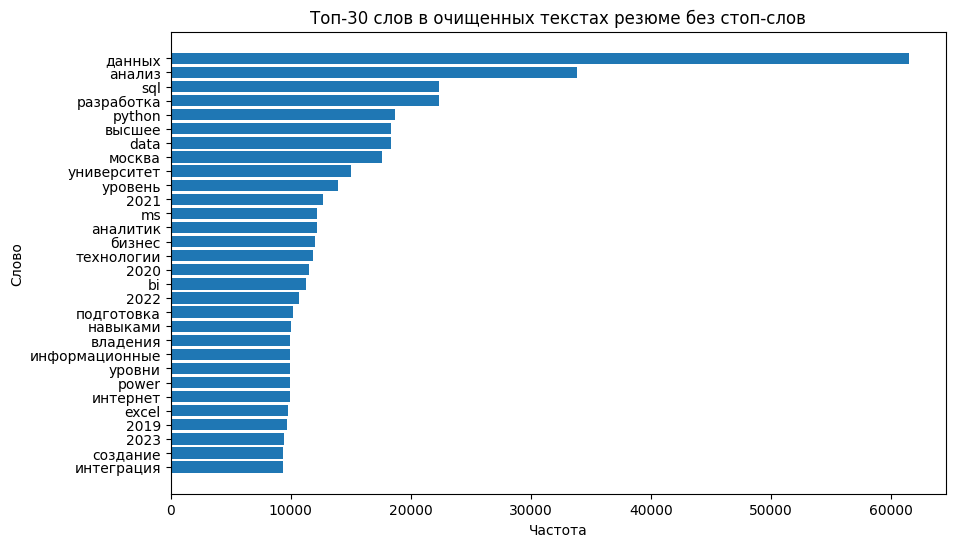

,word,count
14563,данных,61502
10135,анализ,33887
7959,sql,22367
31149,разработка,22335
6847,python,18664
13470,высшее,18333
2685,data,18332
22725,москва,17646
37574,университет,15024
37750,уровень,13982


In [250]:
top_words_rez = show_top_words(
    df_rez["text_clean"],
    "Топ-30 слов в очищенных текстах резюме без стоп-слов",
    stop_words=stopwords
)
top_words_rez

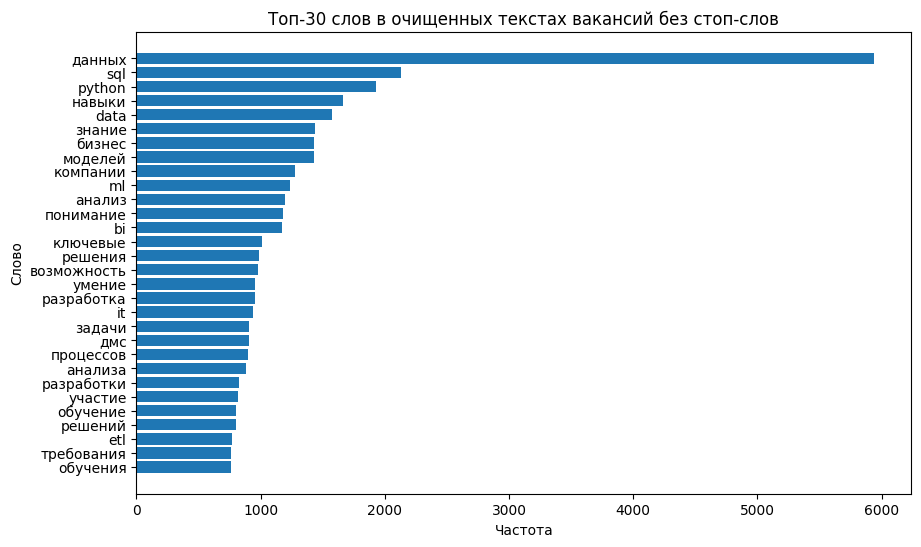

,word,count
7201,данных,5941
3227,sql,2127
2758,python,1927
12969,навыки,1663
1075,data,1576
8988,знание,1438
4857,бизнес,1434
12665,моделей,1428
10649,компании,1280
2224,ml,1238


In [251]:
top_words_vac = show_top_words(
    df_vac["text_clean"],
    "Топ-30 слов в очищенных текстах вакансий без стоп-слов",
    stop_words=stopwords
)
top_words_vac

Проверим также самые популярные слова без удаления стоп-слов

Резюме:

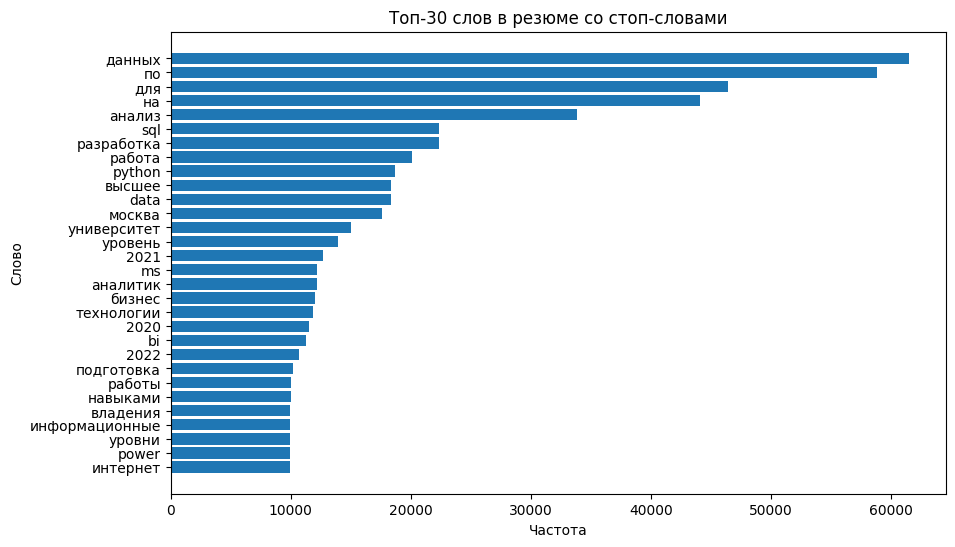

,word,count
14588,данных,61502
27499,по,58833
15341,для,46473
23029,на,44140
10150,анализ,33887
7971,sql,22367
31209,разработка,22335
30856,работа,20116
6859,python,18664
13493,высшее,18333


In [252]:
top_words_rez_raw = show_top_words(
    df_rez["text_clean"],
    "Топ-30 слов в резюме со стоп-словами",
    stop_words=None
)
top_words_rez_raw

Вакансии:

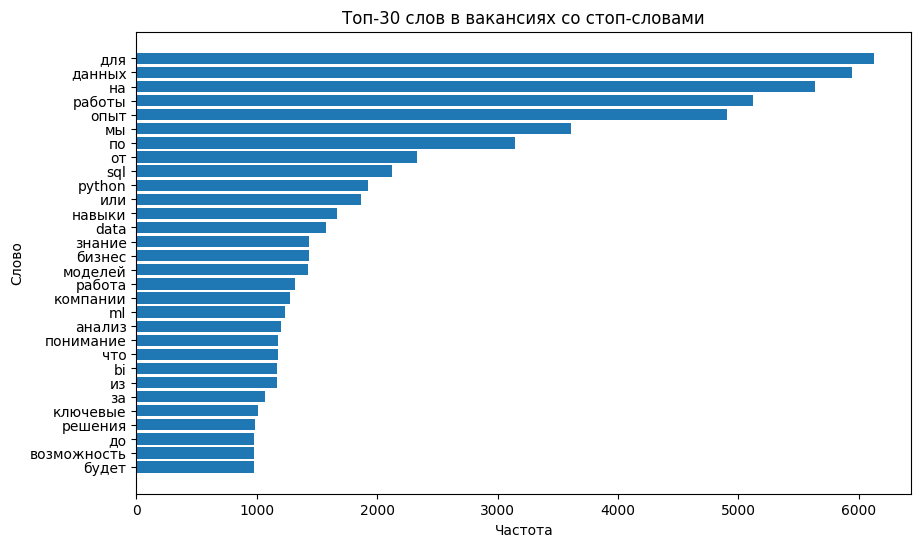

,word,count
7732,для,6129
7225,данных,5941
12978,на,5633
18939,работы,5124
14790,опыт,4906
12945,мы,3606
16233,по,3141
15046,от,2328
3238,sql,2127
2769,python,1927


In [253]:
top_words_vac_raw = show_top_words(
    df_vac["text_clean"],
    "Топ-30 слов в вакансиях со стоп-словами",
    stop_words=None
)

top_words_vac_raw

Видим, что в тексте встречается много стоп-слов - такие слова встречаются часто, но не отражают профессиональную специфику. Удалим эти слова.

Дополнительно уберем некоторые часто встречающиеся слова, характерные для наполнения резюме и вакансий, например «работа», «опыт», «год».

In [254]:
stopwords_set = set(stopwords)

def remove_stopwords(text):
    text = str(text).lower()
    words = re.findall(r"[а-яёa-z0-9+#.]+", text)
    words = [
        word for word in words
        if word not in stopwords_set
    ]
    return " ".join(words)

df_rez["text_clean"] = df_rez["text_clean"].apply(remove_stopwords)
df_vac["text_clean"] = df_vac["text_clean"].apply(remove_stopwords)

### Анализ биграмм

In [255]:
def show_top_ngrams(texts, title, ngram_range=(2, 2), top_n=30):
    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=stopwords,
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b[а-яёa-z0-9+#.]{2,}\b"
    )
    X = vectorizer.fit_transform(texts.fillna("").astype(str))
    terms = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1
    result = pd.DataFrame({
        "term": terms,
        "count": counts
    }).sort_values("count", ascending=False).head(top_n)
    plt.figure(figsize=(10, 6))
    plt.barh(result["term"][::-1], result["count"][::-1])
    plt.title(title)
    plt.xlabel("Частота")
    plt.ylabel("Фраза")
    plt.show()
    
    return result

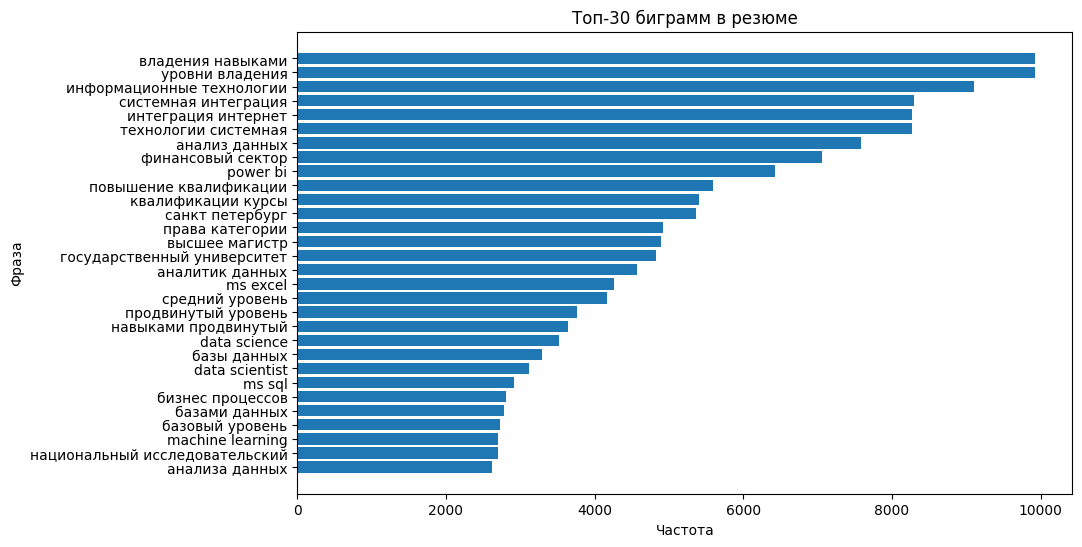

,term,count
58847,владения навыками,9928
208934,уровни владения,9928
89677,информационные технологии,9101
184780,системная интеграция,8297
88066,интеграция интернет,8270
201812,технологии системная,8270
45982,анализ данных,7580
213413,финансовый сектор,7056
31172,power bi,6430
144178,повышение квалификации,5593


In [256]:
top_bigrams_rez = show_top_ngrams(
    df_rez["text_clean"],
    "Топ-30 биграмм в резюме",
    ngram_range=(2, 2)
)
top_bigrams_rez

### Облака слов

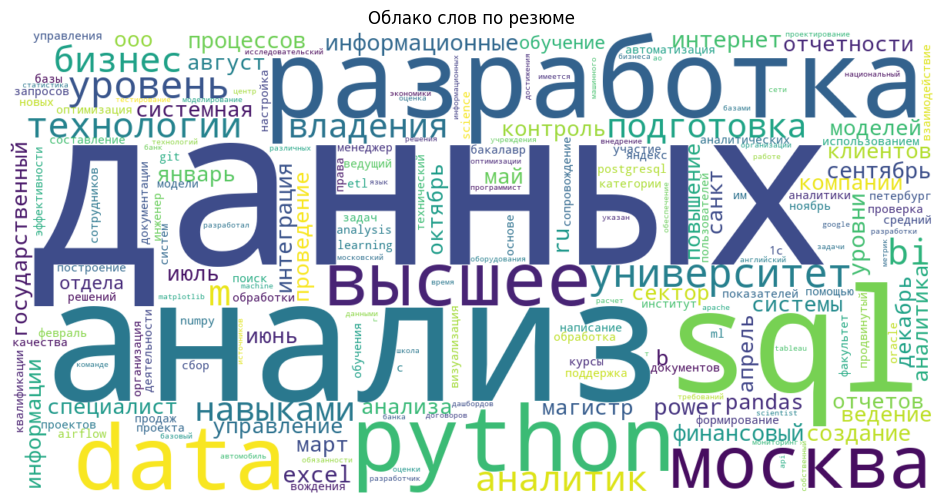

In [257]:
resume_text = " ".join(df_rez["text_clean"].dropna().astype(str))
wordcloud_rez = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=set(stopwords),
    collocations=False
).generate(resume_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_rez, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов по резюме")
plt.show()

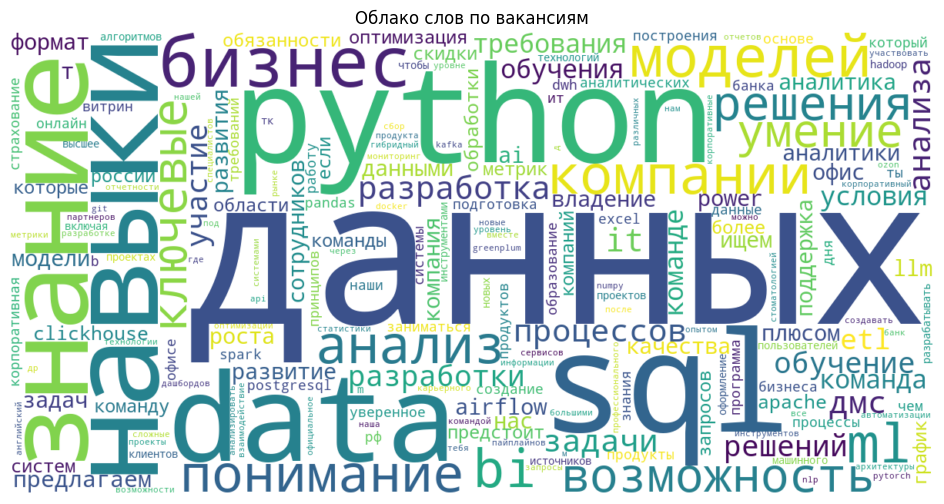

In [258]:
vacancy_text = " ".join(df_vac["text_clean"].dropna().astype(str))

wordcloud_vac = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=set(stopwords),
    collocations=False
).generate(vacancy_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_vac, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов по вакансиям")
plt.show()

В ходе рассмотрения облака слов выявлено, что остались малоинформативные слова, которые также следует удалить

In [259]:
extra_stopwords = [
    # образование, даты, города
    "уровень", "уровни", "владения", "владение",
    "высшее", "университет", "институт",
    "москва", "санкт", "петербург",
    "государственный", "финансовый",
    "январь", "февраль", "март", "апрель", "май", "июнь", "июль",
    "август", "сентябрь", "октябрь", "ноябрь", "декабрь",

    # общие слова из резюме
    "проектов", "проекта", "курсы", "обучение", "участие",
    "создание", "ведение", "подготовка", "формирование",
    "составление", "контроль", "основе", "основ",

    # HR-шаблоны из вакансий
    "компании", "компания", "команду", "команда", "команде",
    "сотрудников", "условия", "возможность", "роста",
    "ищем", "предстоит", "помогать",
    "которые", "который", "наш", "наши", "нам",
    "тебя", "ты", "тебе", "если", "более",

    # слишком общие слова
    "решения", "решений", "задачи", "задач",
    "требования", "обязанности",
    "развитие", "поддержка", "оптимизация",
    "запросов", "процессов", "процессы",
    "корпоративная", "оформление"
]

stopwords = stopwords + extra_stopwords
stopwords_set = set(stopwords)

In [260]:
df_rez["text_clean"] = df_rez["text_clean"].apply(remove_stopwords)
df_vac["text_clean"] = df_vac["text_clean"].apply(remove_stopwords)

### Анализ навыков кандидата / требуемых навыков

In [261]:
df_rez["skills_count"] = df_rez["skills_list"].apply(len)
df_vac["skills_count"] = df_vac["skills_final"].apply(len)

In [262]:
pd.DataFrame({
    "Количество навыков в резюме": df_rez["skills_count"].describe(),
    "Количество навыков в вакансиях": df_vac["skills_count"].describe()
})

,Количество навыков в резюме,Количество навыков в вакансиях
count,10118.000000,1404.000000
mean,17.628484,9.213675
std,8.810529,6.691336
min,0.000000,0.000000
25%,11.000000,4.000000
50%,17.000000,8.000000
75%,25.000000,13.000000
max,65.000000,44.000000


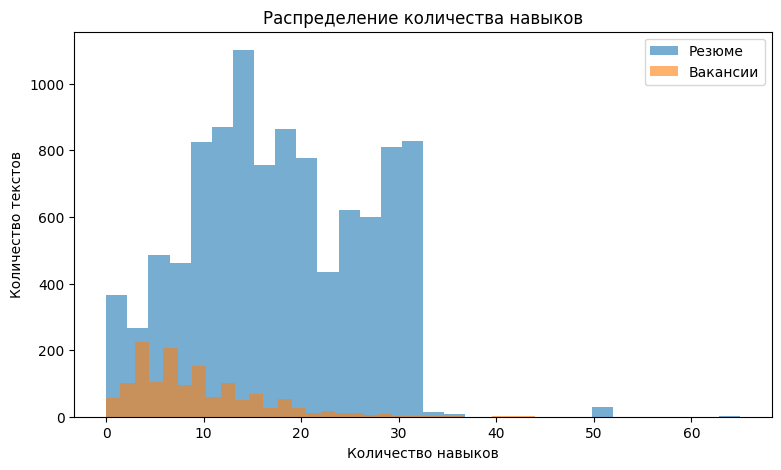

In [263]:
plt.figure(figsize=(9, 5))

plt.hist(df_rez["skills_count"], bins=30, alpha=0.6, label="Резюме")
plt.hist(df_vac["skills_count"], bins=30, alpha=0.6, label="Вакансии")

plt.title("Распределение количества навыков")
plt.xlabel("Количество навыков")
plt.ylabel("Количество текстов")
plt.legend()
plt.show()

Видим вакансии и резюме, в которых указано аномально много навыков (40, 50, 60+). Возможно, данная ситуация является нормальной в некоторых случаях, но на всякий случай удалим их (чтобы не искажать псефдоразметку)

Удалим через 99-ый процентиль (по графику видим, что таких случаев немного)

In [264]:
rez_skills_limit = df_rez["skills_count"].quantile(0.99)
vac_skills_limit = df_vac["skills_count"].quantile(0.99)

print("Порог для резюме:", rez_skills_limit)
print("Порог для вакансий:", vac_skills_limit)

Порог для резюме: 32.0
Порог для вакансий: 30.0


In [265]:
rez_outliers_count = (df_rez["skills_count"] > rez_skills_limit).sum()
vac_outliers_count = (df_vac["skills_count"] > vac_skills_limit).sum()

print("Резюме-выбросы:", rez_outliers_count)
print("Доля резюме-выбросов:", round(rez_outliers_count / len(df_rez), 3))

print("Вакансии-выбросы:", vac_outliers_count)
print("Доля вакансий-выбросов:", round(vac_outliers_count / len(df_vac), 3))

Резюме-выбросы: 51
Доля резюме-выбросов: 0.005
Вакансии-выбросы: 14
Доля вакансий-выбросов: 0.01


In [266]:
df_rez = df_rez[df_rez["skills_count"] <= rez_skills_limit]
df_vac = df_vac[df_vac["skills_count"] <= vac_skills_limit]

In [267]:
resume_skills = sum(df_rez["skills_list"], [])
vacancy_skills = sum(df_vac["skills_final"], [])

In [268]:
top_resume_skills = pd.DataFrame(
    Counter(resume_skills).most_common(30),
    columns=["skill", "count"]
)
top_resume_skills

,skill,count
0,python,6988
1,sql,6455
2,анализ данных,3168
3,ms excel,3143
4,git,3073
5,pandas,2981
6,базовый уровень,2623
7,postgresql,2546
8,уровень не указан,2496
9,power bi,2209


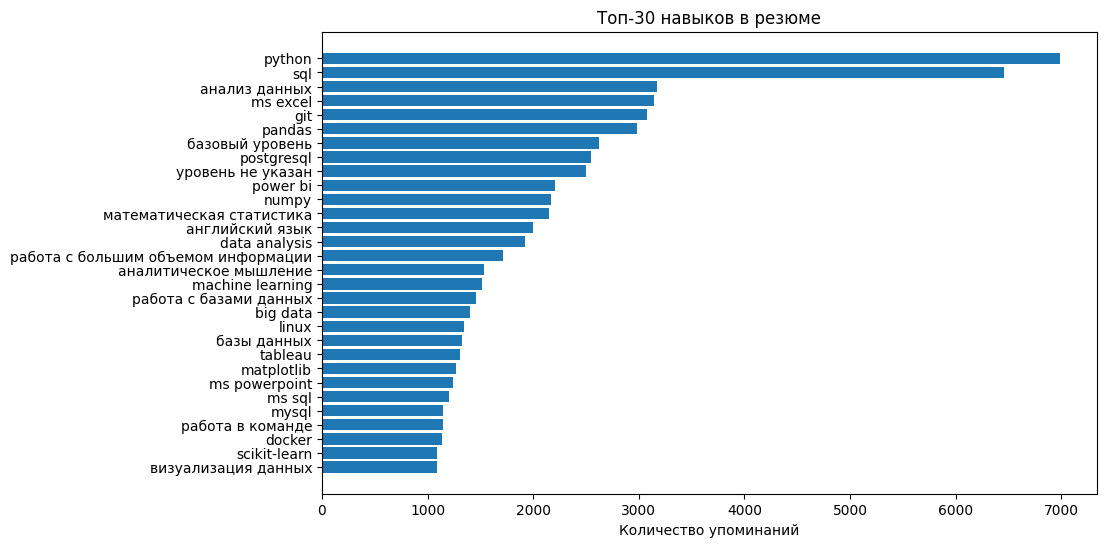

In [269]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_resume_skills["skill"][::-1],
    top_resume_skills["count"][::-1]
)

plt.title("Топ-30 навыков в резюме")
plt.xlabel("Количество упоминаний")
plt.show()

In [270]:
top_vacancy_skills = pd.DataFrame(
    Counter(vacancy_skills).most_common(30),
    columns=["skill", "count"]
)
top_vacancy_skills

,skill,count
0,python,959
1,sql,894
2,postgresql,250
3,pandas,249
4,clickhouse,240
5,power bi,221
6,numpy,189
7,airflow,186
8,pytorch,165
9,задайте вопрос работодателю,151


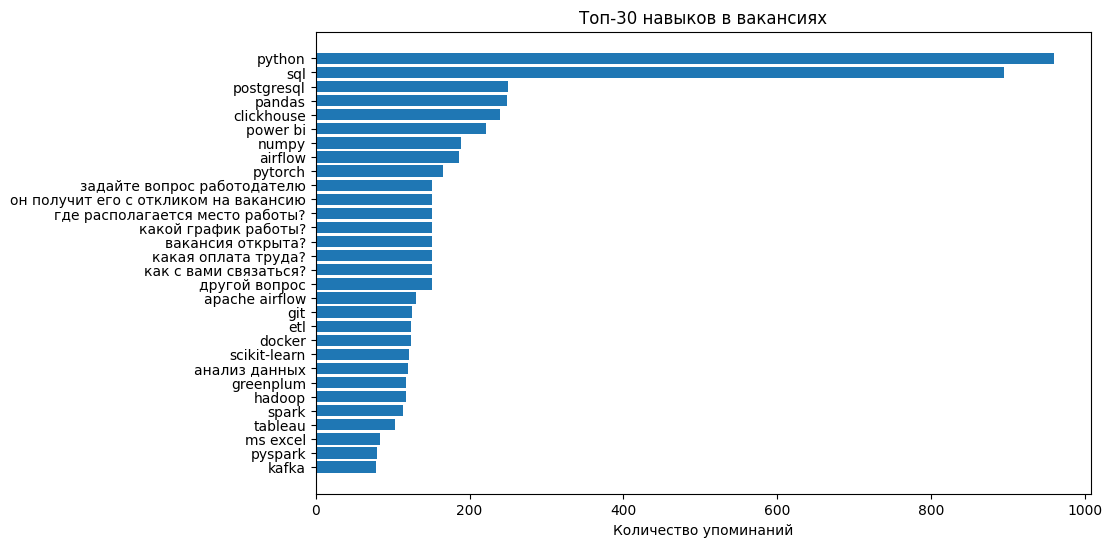

In [271]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_vacancy_skills["skill"][::-1],
    top_vacancy_skills["count"][::-1]
)
plt.title("Топ-30 навыков в вакансиях")
plt.xlabel("Количество упоминаний")
plt.show()

### Анализ опыта работы

In [272]:
rez_experience = df_rez["experience_text"].fillna(0)
vac_experience = df_vac["experience_years_min"].fillna(0)

In [273]:
pd.DataFrame({
    "Опыт в резюме": rez_experience.describe(),
    "Опыт в вакансиях (минимальный)": vac_experience.describe()
})

,Опыт в резюме,Опыт в вакансиях (минимальный)
count,10067.000000,1390.000000
mean,9.799134,2.064748
std,6.653439,1.385976
min,0.000000,0.000000
25%,5.170000,1.000000
50%,8.420000,1.000000
75%,13.420000,3.000000
max,46.750000,6.000000


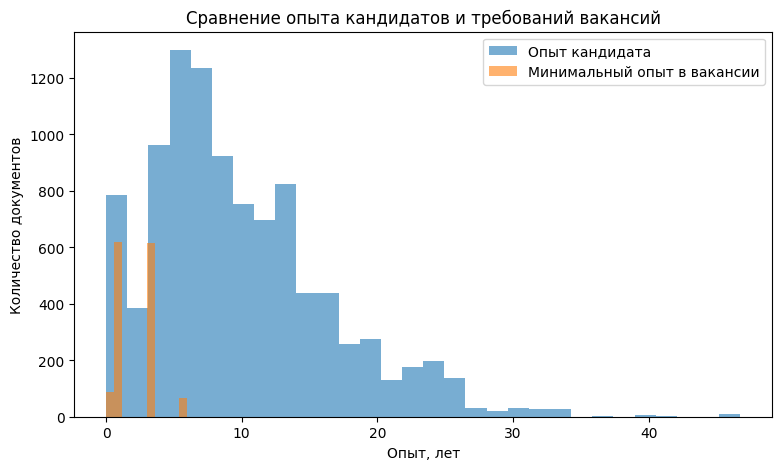

In [274]:
plt.figure(figsize=(9, 5))
plt.hist(rez_experience, bins=30, alpha=0.6, label="Опыт кандидата")
plt.hist(vac_experience, bins=10, alpha=0.6, label="Минимальный опыт в вакансии")
plt.title("Сравнение опыта кандидатов и требований вакансий")
plt.xlabel("Опыт, лет")
plt.ylabel("Количество документов")
plt.legend()
plt.show()

Видим такую же проблему, как и с навыками - в резюме указан слишком большой опыт (с вакансиями такого нет). Это, скорее всего, не ошибка и не ложь, но также удалим для корректности псевдооценки.

Удалим кандидатов с опытом 25+, тк по графику видно, что после остается не так много значений

In [275]:
rez_exp_limit = 25

print("Количество резюме до фильтрации:", len(df_rez))

rez_big_exp_count = (df_rez["experience_text"] > rez_exp_limit).sum()
rez_big_exp_share = rez_big_exp_count / len(df_rez)

print("Резюме с опытом больше 25 лет:", rez_big_exp_count)
print("Доля таких резюме:", round(rez_big_exp_share, 3))

Количество резюме до фильтрации: 10067
Резюме с опытом больше 25 лет: 293
Доля таких резюме: 0.029


In [276]:
df_rez = df_rez[df_rez["experience_text"] <= rez_exp_limit]

Рассмотрим распределение опыта по груммам

In [277]:
def make_experience_group(x):
    if x == 0:
        return "0 лет / не указано"
    elif x < 1:
        return "до 1 года"
    elif x < 3:
        return "1–3 года"
    elif x < 6:
        return "3–6 лет"
    else:
        return "6+ лет"

In [278]:
rez_exp_group = rez_experience.apply(make_experience_group)
vac_exp_group = vac_experience.apply(make_experience_group)

In [279]:
experience_group_compare = pd.DataFrame({
    "resume": rez_exp_group.value_counts(normalize=True),
    "vacancy": vac_exp_group.value_counts(normalize=True)
}).fillna(0)
experience_group_compare

,resume,vacancy
0 лет / не указано,0.042416,0.063309
1–3 года,0.045396,0.446043
3–6 лет,0.213867,0.441727
6+ лет,0.673885,0.048921
до 1 года,0.024436,0.000000


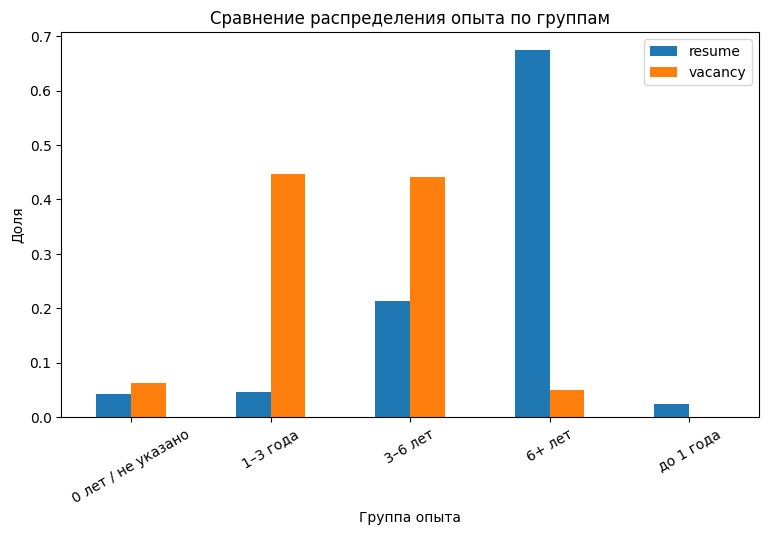

In [280]:
experience_group_compare.plot(kind="bar", figsize=(9, 5))

plt.title("Сравнение распределения опыта по группам")
plt.xlabel("Группа опыта")
plt.ylabel("Доля")
plt.xticks(rotation=30)
plt.show()

### Анализ названий должностей

In [281]:
top_resume_titles = (
    df_rez["resume_title"]
    .str.lower()
    .str.strip()
    .value_counts()
    .head(30)
)
top_resume_titles

resume_title
аналитик данных                                                                        2308
data scientist                                                                         1610
data analyst                                                                            542
data engineer                                                                           436
продуктовый аналитик                                                                    215
junior data scientist                                                                   125
bi-аналитик                                                                             111
ml engineer                                                                              88
аналитик, data scientist                                                                 65
senior data analyst                                                                      56
аналитик данных \ bi-аналитик                                      

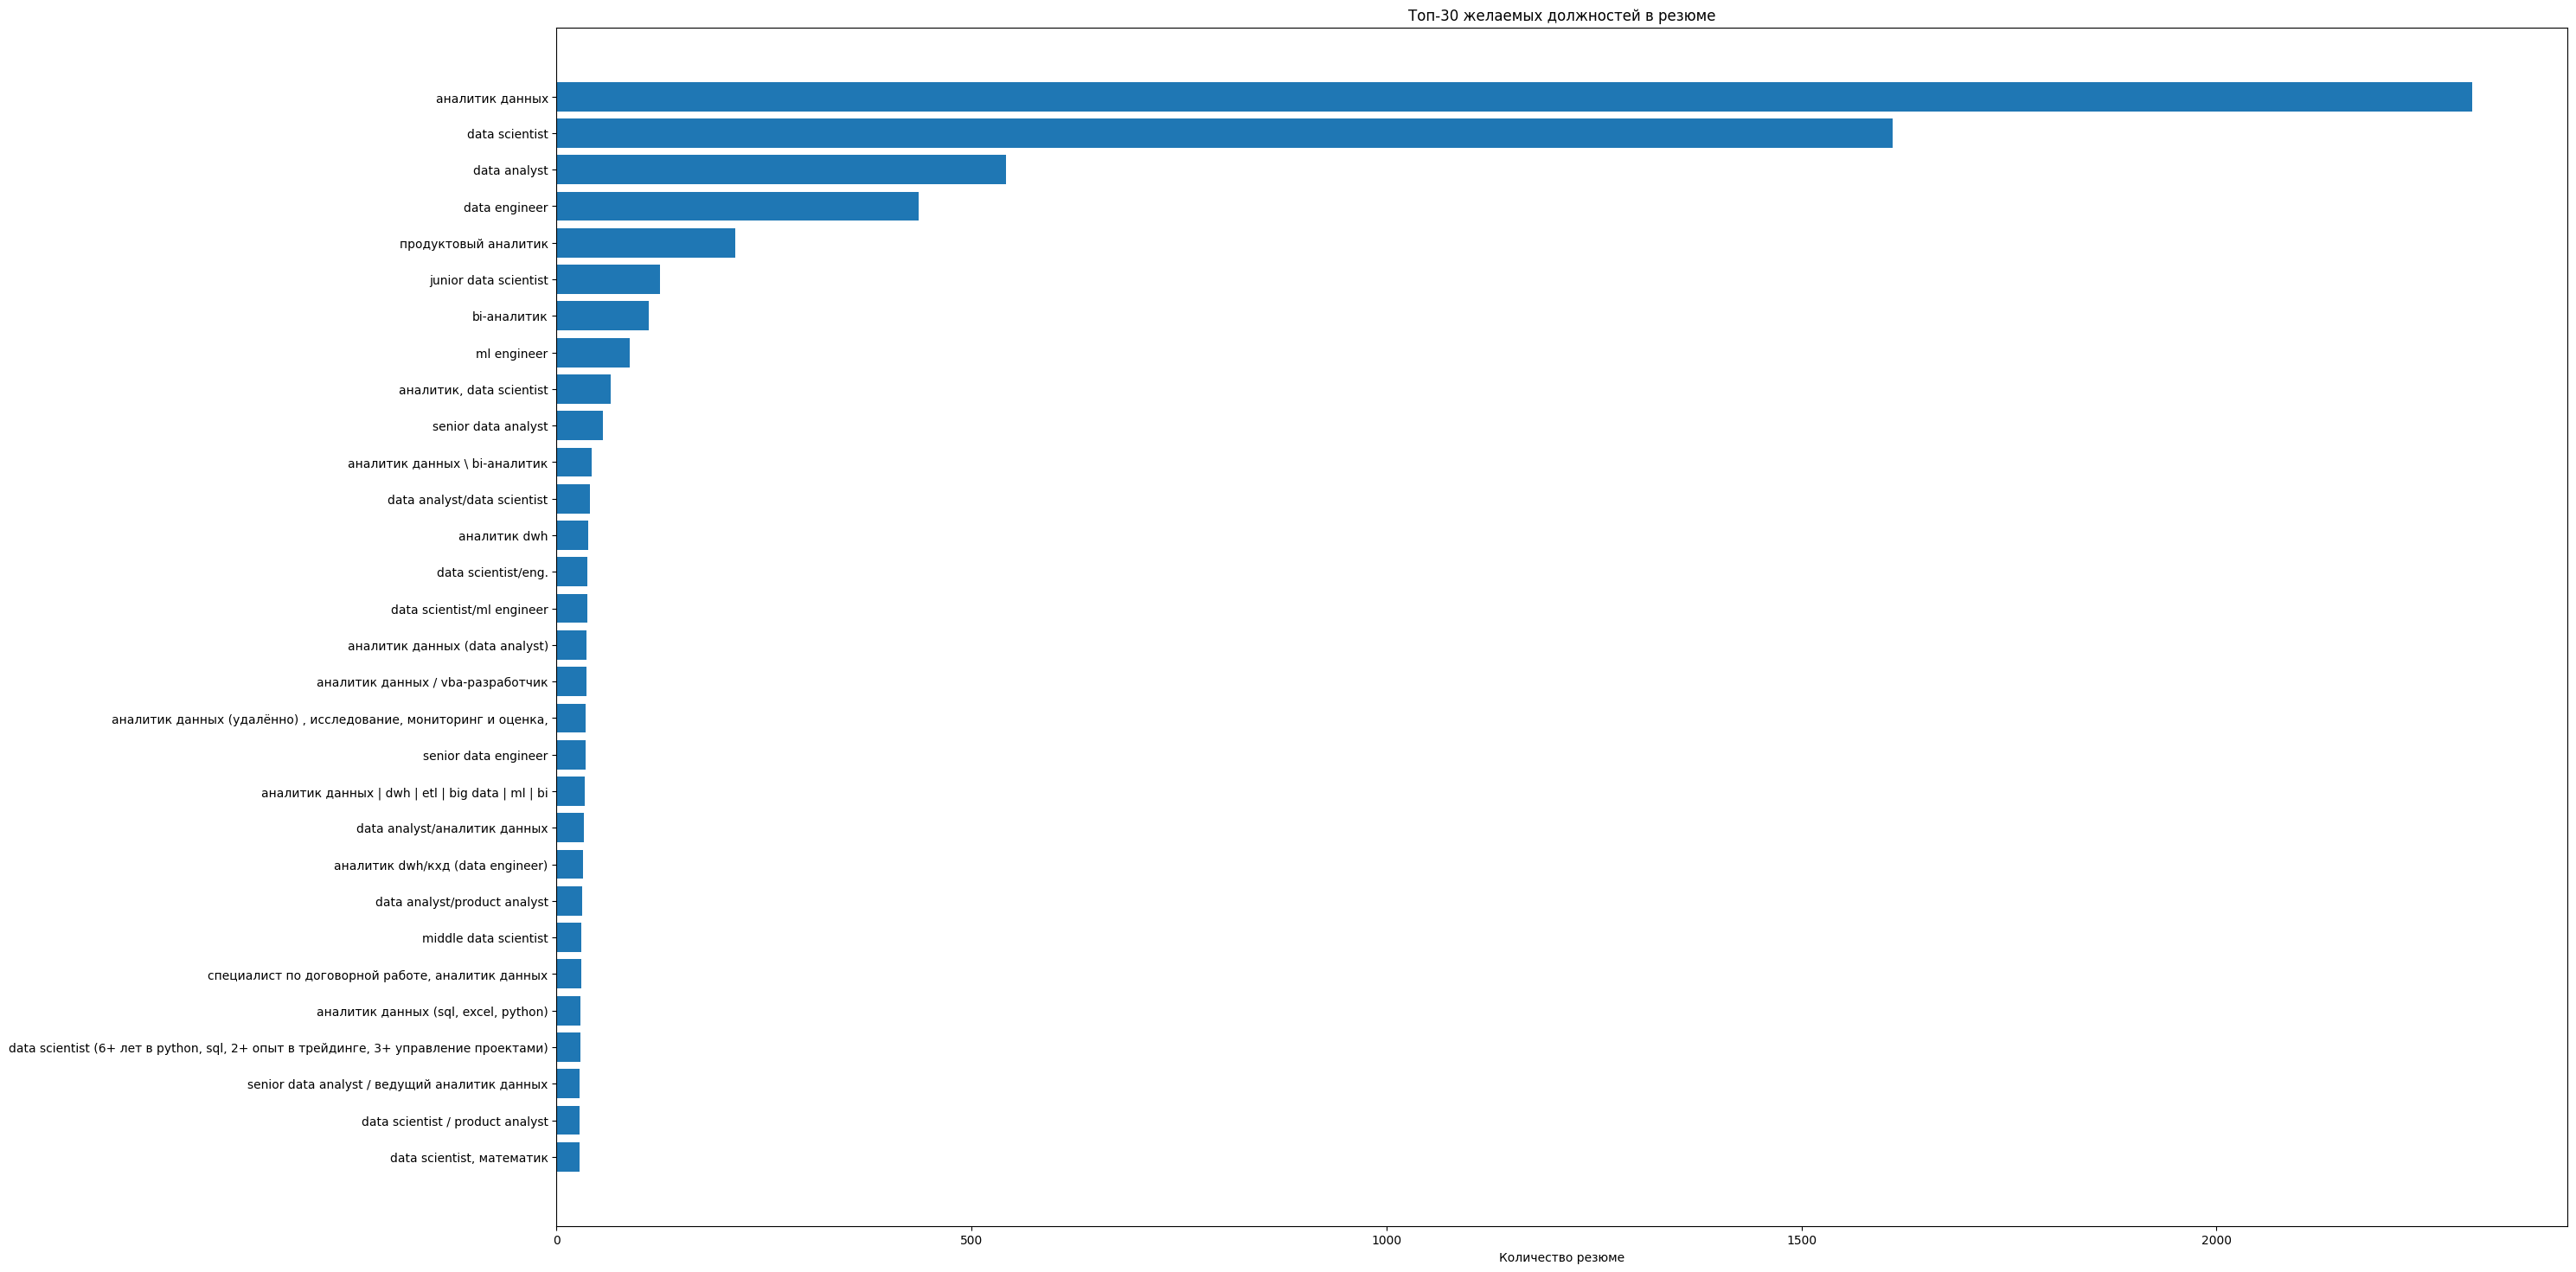

In [282]:
plt.figure(figsize=(30, 18))

plt.barh(
    top_resume_titles.index[::-1],
    top_resume_titles.values[::-1]
)
plt.title("Топ-30 желаемых должностей в резюме")
plt.xlabel("Количество резюме")
plt.show()

### Выводы

В рамках разведочного анализа были изучены подготовленные датасеты резюме и вакансий, полученные после этапов очистки, фильтрации и извлечения признаков. Анализ был направлен на проверку качества данных и оценку пригодности датасетов для дальнейшего построения модели сопоставления резюме и вакансий.

Были проделаны следующие шаги:

1. Проверена общая структура датасетов
2. Проведен анализ очищенных текстов (с удалением правого хвоста графиков длин)
3. Проанализирована доля латиницы (тексты с большим содержанием латиницы были удалены)
4. Выполнен частотный анализ слов - из текстов убраны стоп-слова
5. Проведен анализ биграмм
6. Построены облака слов, , которые позволили выявить дополнительный "шум"
7. Проанализировано количество навыков в резюме и вакансиях (также был удален правый хвост), выявлены наиболее частотные навыки
8. Проанализирован указанный в датасетах опыт работы (для резюме также была удалена правая часть хвоста)
9. Также были рассмотрены популярные названия должностей

## Сохранение результата

In [283]:
df_vac.to_csv("df_vac_new.csv", index=False)
df_rez.to_csv("df_rez_new.csv", index=False)